In [1]:
import json
import pandas as pd

### JSON vs JSONL

- **JSON** stores one complete object or array in a single file.
- **JSONL** stores one JSON object per line, which is easier for streaming and large datasets.


In [2]:
from pathlib import Path

path = Path('/Users/kishorkumarparoi/Desktop/Maven - The AI Engineering Bootcamp /Resources/AIE5-main/22_Rag_Qdrant_Hybrid_Search_Pipeline/data/Electronics_10mb.jsonl')

In [3]:
%pwd

'/Users/kishorkumarparoi/Desktop/Maven - The AI Engineering Bootcamp /Resources/AIE5-main/22_Rag_Qdrant_Hybrid_Search_Pipeline/notebooks/week_1/research'

In [4]:
df = pd.read_json(path, lines=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2026 entries, 0 to 2025
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   main_category    2000 non-null   object 
 1   title            2026 non-null   object 
 2   average_rating   2026 non-null   float64
 3   rating_number    2026 non-null   int64  
 4   features         2026 non-null   object 
 5   description      2026 non-null   object 
 6   price            864 non-null    float64
 7   images           2026 non-null   object 
 8   videos           2026 non-null   object 
 9   store            2013 non-null   object 
 10  categories       2026 non-null   object 
 11  details          2026 non-null   object 
 12  parent_asin      2026 non-null   object 
 13  bought_together  0 non-null      float64
 14  subtitle         1 non-null      object 
 15  author           0 non-null      float64
dtypes: float64(4), int64(1), object(11)
memory usage: 253.4+ KB


In [6]:
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Electronics,FS-1051 FATSHARK TELEPORTER V3 HEADSET,3.5,6,[],[Teleporter V3 The “Teleporter V3” kit sets a ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Fat Shark,"[Electronics, Television & Video, Video Glasses]","{'Date First Available': 'August 2, 2014', 'Ma...",B00MCW7G9M,NaN,NaN,NaN
1,All Electronics,Ce-H22B12-S1 4Kx2K Hdmi 4Port,5.0,1,"[UPC: 662774021904, Weight: 0.600 lbs]",[HDMI In - HDMI Out],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],SIIG,"[Electronics, Television & Video, Accessories,...",{'Product Dimensions': '0.83 x 4.17 x 2.05 inc...,B00YT6XQSE,NaN,NaN,NaN
2,Computers,Digi-Tatoo Decal Skin Compatible With MacBook ...,4.5,246,[WARNING: Please IDENTIFY MODEL NUMBER on the ...,[],19.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'AL 2Sides Video', 'url': 'https://...",Digi-Tatoo,"[Electronics, Computers & Accessories, Laptop ...","{'Brand': 'Digi-Tatoo', 'Color': 'Fresh Marble...",B07SM135LS,NaN,NaN,NaN
3,AMAZON FASHION,NotoCity Compatible with Vivoactive 4 band 22m...,4.5,233,[☛NotoCity 22mm band is designed for Vivoactiv...,[],9.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],NotoCity,"[Electronics, Wearable Technology, Clips, Arm ...","{'Date First Available': 'May 29, 2020', 'Manu...",B089CNGZCW,NaN,NaN,NaN
4,Cell Phones & Accessories,Motorola Droid X Essentials Combo Pack,3.8,64,"[New Droid X Essentials Combo Pack, Exclusive ...",[all Genuine High Quality Motorola Made Access...,14.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],Verizon,"[Electronics, Computers & Accessories, Compute...",{'Product Dimensions': '11.6 x 6.9 x 3.1 inche...,B004E2Z88O,NaN,NaN,NaN


In [8]:
with open('../../../data/Electronics_10mb.jsonl', 'r', encoding='utf-8') as file_handle:
    for _ in range(5):
        line = file_handle.readline()
        review_record = json.loads(line)
        print(review_record)

{'main_category': 'All Electronics', 'title': 'FS-1051 FATSHARK TELEPORTER V3 HEADSET', 'average_rating': 3.5, 'rating_number': 6, 'features': [], 'description': ['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.'], 'price': None, 'images': [{'thumb': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_US40_.jpg', 'large': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_.jpg', 'var

In [9]:
with open('../../../data/data.jsonl', 'r', encoding='utf-8') as file_handle:
   first_line = json.loads(file_handle.readline())

In [10]:
first_line

{'main_category': 'All Electronics',
 'title': 'FS-1051 FATSHARK TELEPORTER V3 HEADSET',
 'average_rating': 3.5,
 'rating_number': 6,
 'features': [],
 'description': ['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.'],
 'price': None,
 'images': [{'thumb': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_US40_.jpg',
   'large': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_.

Filter Items that has been observed first item after 2022

In [11]:
def filter_data(data: dict) -> bool:
    try:
        date_str = data.get("details", {}).get("Date First Available", "")
        if date_str:
            datetime.strptime(date_str, "%B %d, %Y")
            return True
        else:
            return False
    except ValueError:
        pass
    return False

In [17]:
with open('../../../data/data.jsonl', 'r', encoding='utf-8') as fp, \
    open('../../../data/Data_With_Images.jsonl', 'w', encoding='utf-8') as fp_out, \
    open('../../../data/Data_No_Images.jsonl', 'w', encoding='utf-8') as fp_no_date:
    i = 0
    for line in fp:
       data = json.loads(line.strip())
       i += 1
       details = data.get("images")
       # Records without details -> separate file
       if not details:
          json.dump(data, fp_no_date)
          fp_no_date.write('\n')
          fp_no_date.flush()
          continue
       # Write all records that have details
       json.dump(data, fp_out)
       fp_out.write('\n')
       fp_out.flush()


In [18]:
df = pd.read_json('../../../data/Data_With_Images.jsonl', lines=True)
print(df.head())

               main_category  \
0            All Electronics   
1            All Electronics   
2                  Computers   
3             AMAZON FASHION   
4  Cell Phones & Accessories   

                                               title  average_rating  \
0             FS-1051 FATSHARK TELEPORTER V3 HEADSET             3.5   
1                      Ce-H22B12-S1 4Kx2K Hdmi 4Port             5.0   
2  Digi-Tatoo Decal Skin Compatible With MacBook ...             4.5   
3  NotoCity Compatible with Vivoactive 4 band 22m...             4.5   
4             Motorola Droid X Essentials Combo Pack             3.8   

   rating_number                                           features  \
0              6                                                 []   
1              1             [UPC: 662774021904, Weight: 0.600 lbs]   
2            246  [WARNING: Please IDENTIFY MODEL NUMBER on the ...   
3            233  [☛NotoCity 22mm band is designed for Vivoactiv...   
4             64  [

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2026 entries, 0 to 2025
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   main_category    2000 non-null   object 
 1   title            2026 non-null   object 
 2   average_rating   2026 non-null   float64
 3   rating_number    2026 non-null   int64  
 4   features         2026 non-null   object 
 5   description      2026 non-null   object 
 6   price            864 non-null    float64
 7   images           2026 non-null   object 
 8   videos           2026 non-null   object 
 9   store            2013 non-null   object 
 10  categories       2026 non-null   object 
 11  details          2026 non-null   object 
 12  parent_asin      2026 non-null   object 
 13  bought_together  0 non-null      float64
 14  subtitle         1 non-null      object 
 15  author           0 non-null      float64
dtypes: float64(4), int64(1), object(11)
memory usage: 253.4+ KB


<Axes: xlabel='rating_number'>

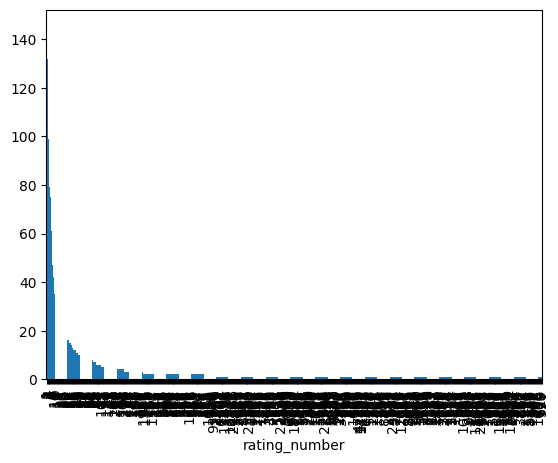

In [20]:
df['rating_number'].value_counts().plot(kind='bar')

In [21]:
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Electronics,FS-1051 FATSHARK TELEPORTER V3 HEADSET,3.5,6,[],[Teleporter V3 The “Teleporter V3” kit sets a ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Fat Shark,"[Electronics, Television & Video, Video Glasses]","{'Date First Available': 'August 2, 2014', 'Ma...",B00MCW7G9M,NaN,NaN,NaN
1,All Electronics,Ce-H22B12-S1 4Kx2K Hdmi 4Port,5.0,1,"[UPC: 662774021904, Weight: 0.600 lbs]",[HDMI In - HDMI Out],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],SIIG,"[Electronics, Television & Video, Accessories,...",{'Product Dimensions': '0.83 x 4.17 x 2.05 inc...,B00YT6XQSE,NaN,NaN,NaN
2,Computers,Digi-Tatoo Decal Skin Compatible With MacBook ...,4.5,246,[WARNING: Please IDENTIFY MODEL NUMBER on the ...,[],19.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'AL 2Sides Video', 'url': 'https://...",Digi-Tatoo,"[Electronics, Computers & Accessories, Laptop ...","{'Brand': 'Digi-Tatoo', 'Color': 'Fresh Marble...",B07SM135LS,NaN,NaN,NaN
3,AMAZON FASHION,NotoCity Compatible with Vivoactive 4 band 22m...,4.5,233,[☛NotoCity 22mm band is designed for Vivoactiv...,[],9.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],NotoCity,"[Electronics, Wearable Technology, Clips, Arm ...","{'Date First Available': 'May 29, 2020', 'Manu...",B089CNGZCW,NaN,NaN,NaN
4,Cell Phones & Accessories,Motorola Droid X Essentials Combo Pack,3.8,64,"[New Droid X Essentials Combo Pack, Exclusive ...",[all Genuine High Quality Motorola Made Access...,14.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],Verizon,"[Electronics, Computers & Accessories, Compute...",{'Product Dimensions': '11.6 x 6.9 x 3.1 inche...,B004E2Z88O,NaN,NaN,NaN


<Axes: xlabel='rating_number'>

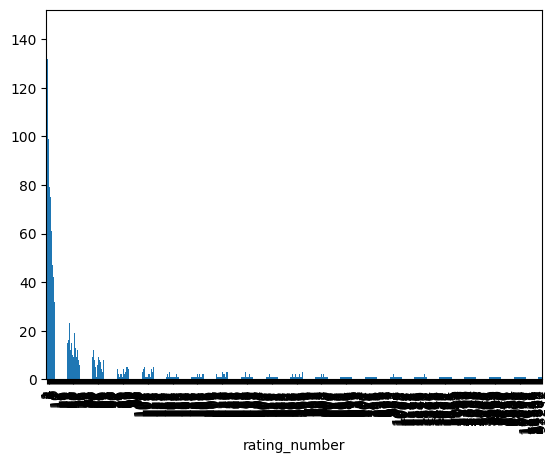

In [23]:
df_ratings = df['rating_number'].value_counts().sort_index()
df_ratings.plot(kind='bar')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2026 entries, 0 to 2025
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   main_category    2000 non-null   object 
 1   title            2026 non-null   object 
 2   average_rating   2026 non-null   float64
 3   rating_number    2026 non-null   int64  
 4   features         2026 non-null   object 
 5   description      2026 non-null   object 
 6   price            864 non-null    float64
 7   images           2026 non-null   object 
 8   videos           2026 non-null   object 
 9   store            2013 non-null   object 
 10  categories       2026 non-null   object 
 11  details          2026 non-null   object 
 12  parent_asin      2026 non-null   object 
 13  bought_together  0 non-null      float64
 14  subtitle         1 non-null      object 
 15  author           0 non-null      float64
dtypes: float64(4), int64(1), object(11)
memory usage: 253.4+ KB
